In [2]:
###### NOTE

# ###### THSI WAS RUN ON A C4D WHERE AS THE FIRST VERSION WAS RUN ON N2D , THE MAC AND C4D SEEM TO PREDORM THE EXACT SAME ... MAYBE THE SAME MATH LIBRATIES ... 
# # BUT THE N2D IS DIFFERENT ...

##### NOTE if you look at the all_preds probabs, you will see that they are very similar but not exactly the same ...

##### NOTE


# HENCE ---- we can use C4D and mac results interchangeably ... not the case with N2D

In [216]:
import pandas as pd
import pickle
import random
import numpy as np
import os
import itertools
from joblib import Parallel, delayed , parallel_backend
from collections import defaultdict
import math
import torch.nn as nn
import json
import copy
from Functions_1_Initial_GS_and_Dist_Analytics_HOD_20_01_21_12 import *

from Results_Dists_V_2 import *
from Equations_Run_Combo_V_2 import *
from Equations_Ensembles_Dist import *
import pickle

import pickle
with open('/Users/cs/Desktop/LSTM_ETF/short_dfs.pkl', 'rb') as f:
    loaded_dfs = pickle.load(f)

with open("/Users/cs/Desktop/LSTM_ETF/lagged_cache.pkl", "rb") as f:
    lagged_cache = pickle.load(f)

#/home/charifslmn/

In [217]:
#                                                       DATA SETS

#### GS data
for i in range(1):   
    with open(f'/Users/cs/Desktop/GS_20_01_to_21_12_chunk_1_22_10percentPOS_Vset_HOD.json', 'r') as f:
        results_GS_ALL = json.load(f)


#### Dist Disc data
with open('/Users/cs/Desktop/top_70_DIST_DISC_GS_20_01_to_21_12_chunk_1_22_10percentPOS_Vset_HOD.json') as f_json:
    results_dist_disc = json.load(f_json)   

    


###### T set with same seed sas val set, neeed sot be organized first 

with open('/Users/cs/Desktop/Tset_NOTsorted_70_models_GS_21_01_to_22_12_DIST_Discovery_10percentPOS_HOD.json') as f:
    results_dist_disc_Tset_NOTsorted_same_seeds = json.load(f)


# ignore = ['val_start_month', 'val_end_month' , 'seed']


##### Organizing the results to have same seeds and combos together --- since params were extracted themselves for GC run simplification 
results_dist_disc_Tset_same_seeds = copy.deepcopy(results_dist_disc_Tset_NOTsorted_same_seeds)

ignore_find_combo = ['val_start_month', 'val_end_month'  ]
### first collect combo_idxs and combo outer info
results_dist_disc_Tset_same_seeds_organized = []
for true in results_dist_disc: ### make sure the combo idx lines up, parallel_backend runs could vary since its the idx when func is called in parallel 
    t_cb_idx = true["combo_index"]

    # same_seed_and_combo = []
    dict_entry = {}
    tt = str({k: v for k, v in true['combo'].items() if k not in ignore_find_combo}).replace(' ', '').replace("'", '').replace('  ', '').replace(',', '')

    for find in results_dist_disc_Tset_same_seeds:

        ff = str({k: v for k, v in find['parameters'].items() if k not in ignore_find_combo}).replace(' ', '').replace("'", '').replace('  ', '').replace(',', '')
        if tt == ff:
            dict_entry["combo_index"] = t_cb_idx
            dict_entry["combo"] = find["parameters"]
            results_dist_disc_Tset_same_seeds_organized.append(dict_entry)
            break
        

ignore_find_seeds = ['val_start_month', 'val_end_month'  , 'seed_num'   ]

### then collect per seed results for each combo , combos are
for entry in results_dist_disc_Tset_same_seeds_organized:
    entry["per_seed_all_results"] = []

    ee = str({k: v for k, v in entry['combo'].items() if k not in ignore_find_seeds}).replace(' ', '').replace("'", '').replace('  ', '').replace(',', '')

    for find in results_dist_disc_Tset_same_seeds:
        ff = str({k: v for k, v in find['parameters'].items() if k not in ignore_find_seeds}).replace(' ', '').replace("'", '').replace('  ', '').replace(',', '')

        if ee == ff:
            seed_entry = {}
            # print(find["parameters"]["seed_num"])
            seed_entry["seed"] = find["parameters"]["seed_num"]
            seed_entry["result_entry"] = find
            entry["per_seed_all_results"].append(seed_entry)

##### Organizing the results to have same seeds and combos together

            


In [218]:
### NOTE consider changing this os that the function chooses the max number of midels possible , this should imporve the resutls in general since 
### seeds of the same model are generally more correalted --- this can also be tested but i am pretty positive this is the case (ran short tests)

### NOTE for now since we want to test the params for model slection , it may be better to keep it as is for standardization

def collect_V_T_set_FULLraw_data(models_selected, results_dist_disc, results_dist_disc_Tset_same_seeds_organized):
    T_set_data = [] 
    V_set_data = []

    # select 5 models at random from the selected models
    models_RAND = random.sample(models_selected, min(15, len(models_selected)))

    for model_entry in models_RAND:
        model_seeds = []
        ff_combo_idx = model_entry['combo_index']
        for seed_entry in model_entry['selected_seeds']:
            seed_num = seed_entry['seed_num']
            model_seeds.append(seed_num)

        ##### Find randomly chosen seeds in the V and T raw data 
        for raw_data_entry_V in results_dist_disc:
            V_combo_idx = raw_data_entry_V["combo_index"]
            if ff_combo_idx == V_combo_idx:
                rand_chosen_seeds = random.sample(model_seeds, min(1, len(model_seeds)))
                for seed_chosen in rand_chosen_seeds:
                    for seed_raw in raw_data_entry_V['per_seed_all_results']:
                        if seed_raw['seed'] == seed_chosen:
                            V_set_data.append(seed_raw['result_entry'])

        for raw_data_entry_T in results_dist_disc_Tset_same_seeds_organized:
            T_combo_idx = raw_data_entry_T["combo_index"]
            if ff_combo_idx == T_combo_idx:
                for seed_chosen in rand_chosen_seeds:
                    for seed_raw in raw_data_entry_T['per_seed_all_results']:
                        if seed_raw['seed'] == seed_chosen:
                            T_set_data.append(seed_raw['result_entry'])

    return {"V_set_data": V_set_data, "T_set_data": T_set_data}


                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

# res = collect_V_T_set_FULLraw_data(Mp_H__param_map_models, results_dist_disc, results_dist_disc_Tset_same_seeds_organized)
# V_set_data = res["V_set_data"] ; T_set_data = res["T_set_data"]
# print(len(V_set_data)) ; print(len(T_set_data))  


In [219]:
import itertools
param_grid = {   
                             "mean_precision_range" : [(1,100),(1,50) ,(50,100) , (30,60)],
                             "max_zero_precision_seeds" : [70],
                             "max_FP_severe_ratio_FPs" : [None],"min_FP_severe_ratio_FPs" : [None],  "min_ratio_difference" : [None], "max_ratio_difference" : [None],

                             "seed_precision_range" : [(1, 50),(50, 100), (30, 60), (1, 100)] , 
                             "seed_min_TPminusFP_greaterEqual" : [None] , "max_seed_severe_FPs_high_bracket" : [None] , "min_seed_TPs_high_bracket" : [None],

                             "seed_recall_range" : [(0, 100), (0,30) , (60,10) , (30,60)],
                             "min_seeds_per_model" : [1],"max_models_to_return" : [70],
                             "max_FP_severe_ratio_FPs_andTPs" : [None], "min_FP_severe_ratio_FPs_andTPs" : [None], "random_seed" : [None]

                               }


keys , vals = param_grid.keys() , param_grid.values()
param_combinations = [dict(zip(keys, v)) for v in itertools.product(*vals)]





In [220]:
param_combinations[0]

{'mean_precision_range': (1, 100),
 'max_zero_precision_seeds': 70,
 'max_FP_severe_ratio_FPs': None,
 'min_FP_severe_ratio_FPs': None,
 'min_ratio_difference': None,
 'max_ratio_difference': None,
 'seed_precision_range': (1, 50),
 'seed_min_TPminusFP_greaterEqual': None,
 'max_seed_severe_FPs_high_bracket': None,
 'min_seed_TPs_high_bracket': None,
 'seed_recall_range': (0, 100),
 'min_seeds_per_model': 1,
 'max_models_to_return': 70,
 'max_FP_severe_ratio_FPs_andTPs': None,
 'min_FP_severe_ratio_FPs_andTPs': None,
 'random_seed': None}

15
15


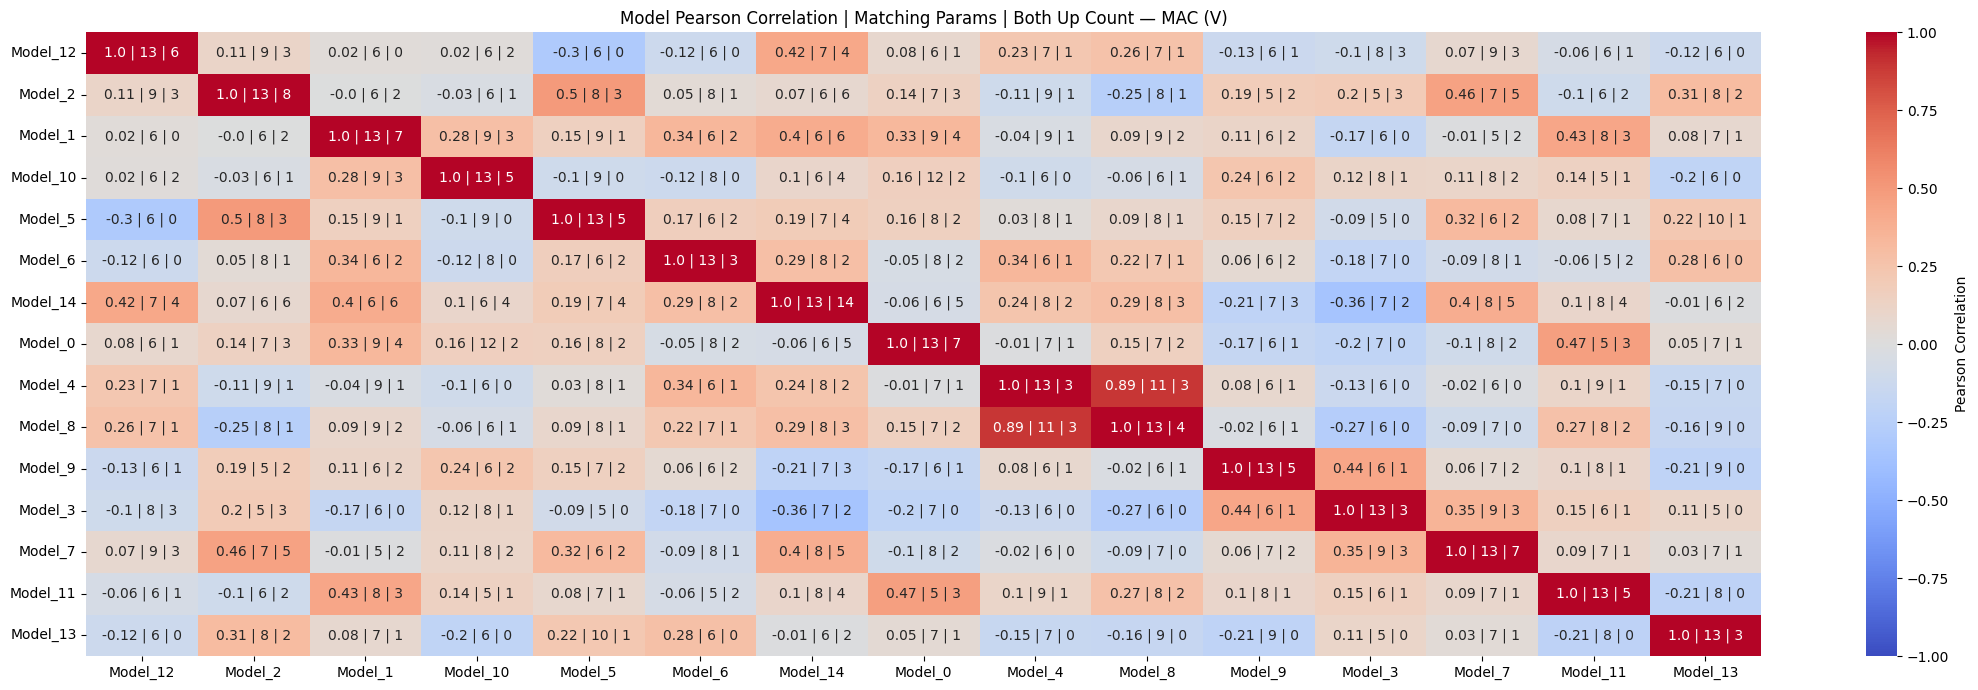

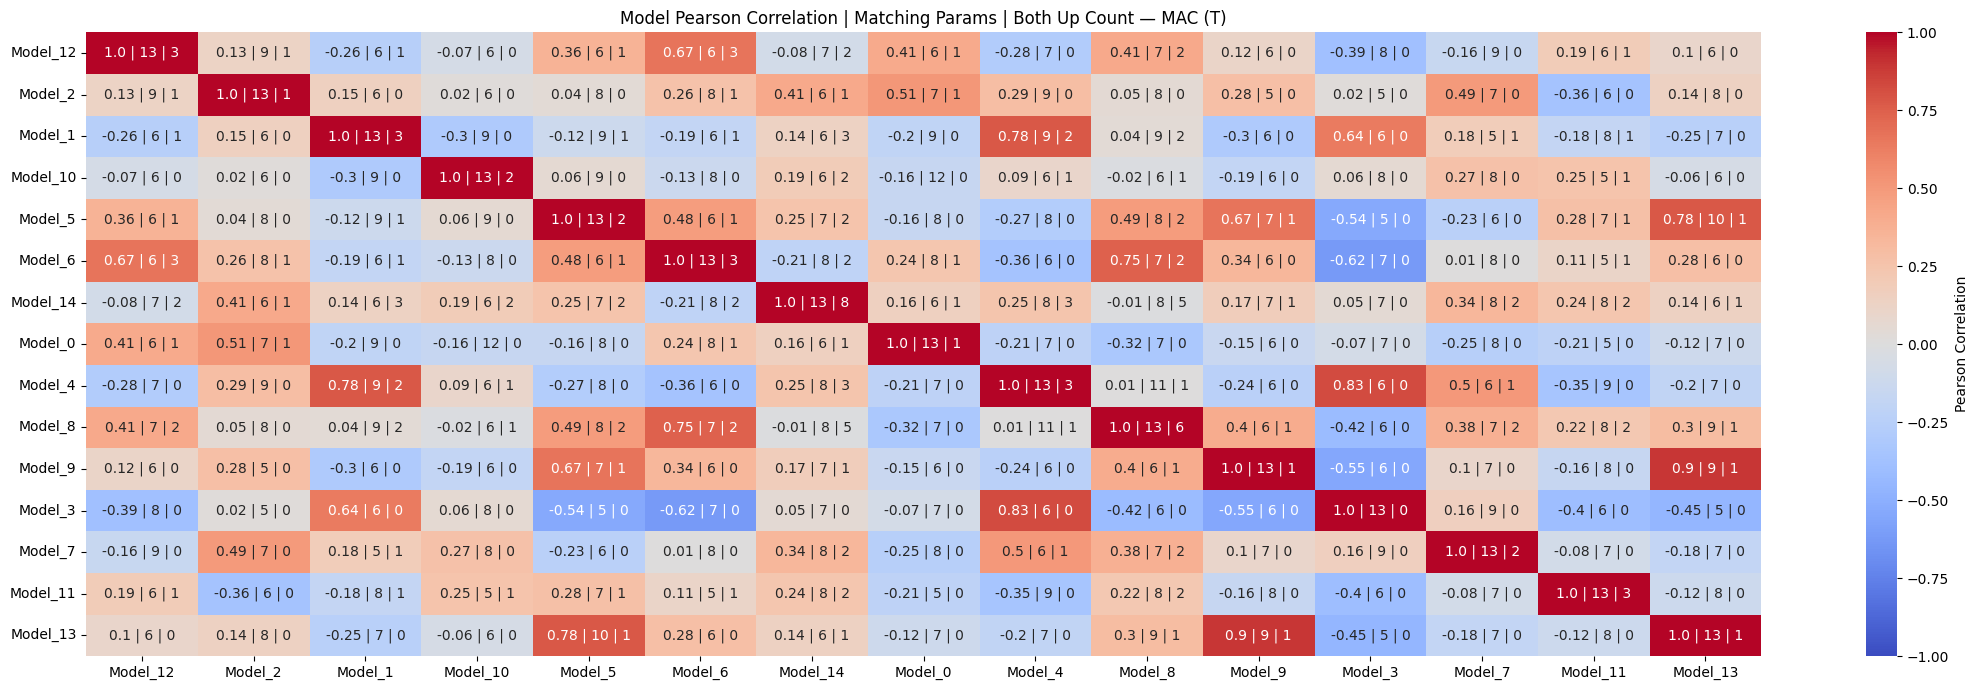

In [221]:
RR = {   
                             "mean_precision_range" : (5, 100),"max_zero_precision_seeds" : 70,
                             "max_FP_severe_ratio_FPs" : None, "min_FP_severe_ratio_FPs" : None,         
                             "min_ratio_difference" : None, "max_ratio_difference" : None,

                             "seed_precision_range" : (1, 40) , 
                             "seed_min_TPminusFP_greaterEqual" : None , 
                             "max_seed_severe_FPs_high_bracket" : None , 
                             "min_seed_TPs_high_bracket" : None ,

                             "seed_recall_range" : (0, 100), "min_seeds_per_model" : 1,
                             "max_models_to_return" : 70, "max_FP_severe_ratio_FPs_andTPs" : None, 
                             "min_FP_severe_ratio_FPs_andTPs" : None ,"random_seed" : None 

                               }

models = select_models_by_criteria(results_dist_disc, **RR)

res = collect_V_T_set_FULLraw_data(models, results_dist_disc, results_dist_disc_Tset_same_seeds_organized)
V = res["V_set_data"] ; T = res["T_set_data"]
print(len(V)) ; print(len(T))

res_mac_val = V
res_mac_val = T

# Add threshold metrics
names_all = [V, T]
names_test = [T]
names_val = [V]

for data in names_all:
    add_threshold_metrics(data, threshold=.7)

# Create DataFrames
df_mac_val = flatten_results(V)
df_mac_test = flatten_results(T)

dfs = [df_mac_val, df_mac_test]

# Add various metrics
add_up_prediction_counts(dfs)
add_false_correct_up_stats(dfs)
flatten_metrics_columns(dfs)

master_df = process_parameters_and_merge(dfs)


corr_res_V = plot_model_corr(master_df, machine="mac", set_type="V", use_spearman=False, use_01_preds=False)
corr_res_T = plot_model_corr(master_df, machine="mac", set_type="T", use_spearman=False, use_01_preds=False)






15
15


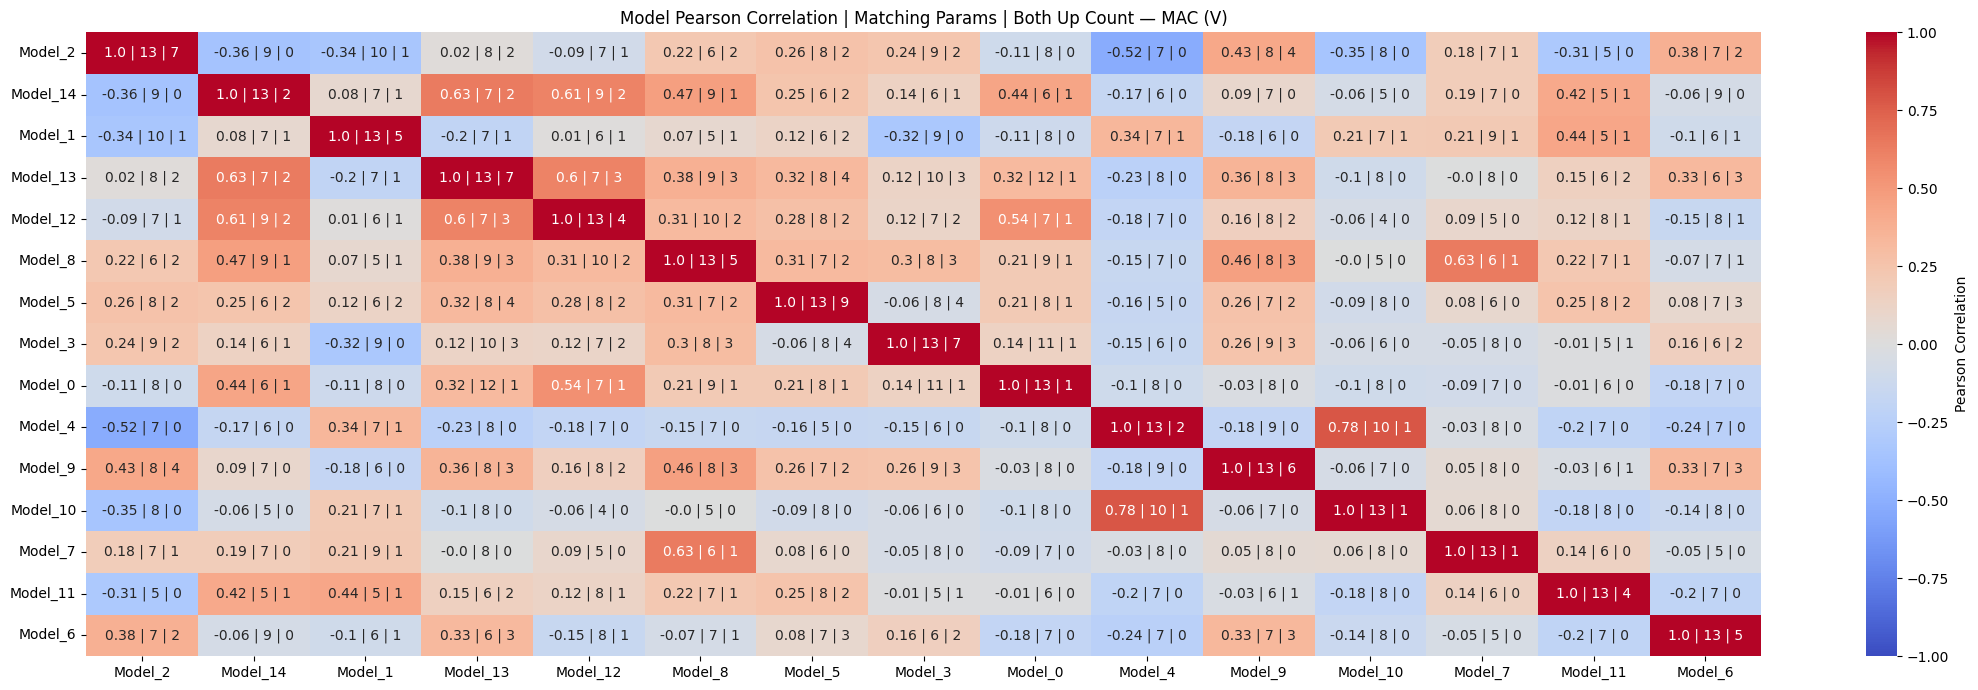

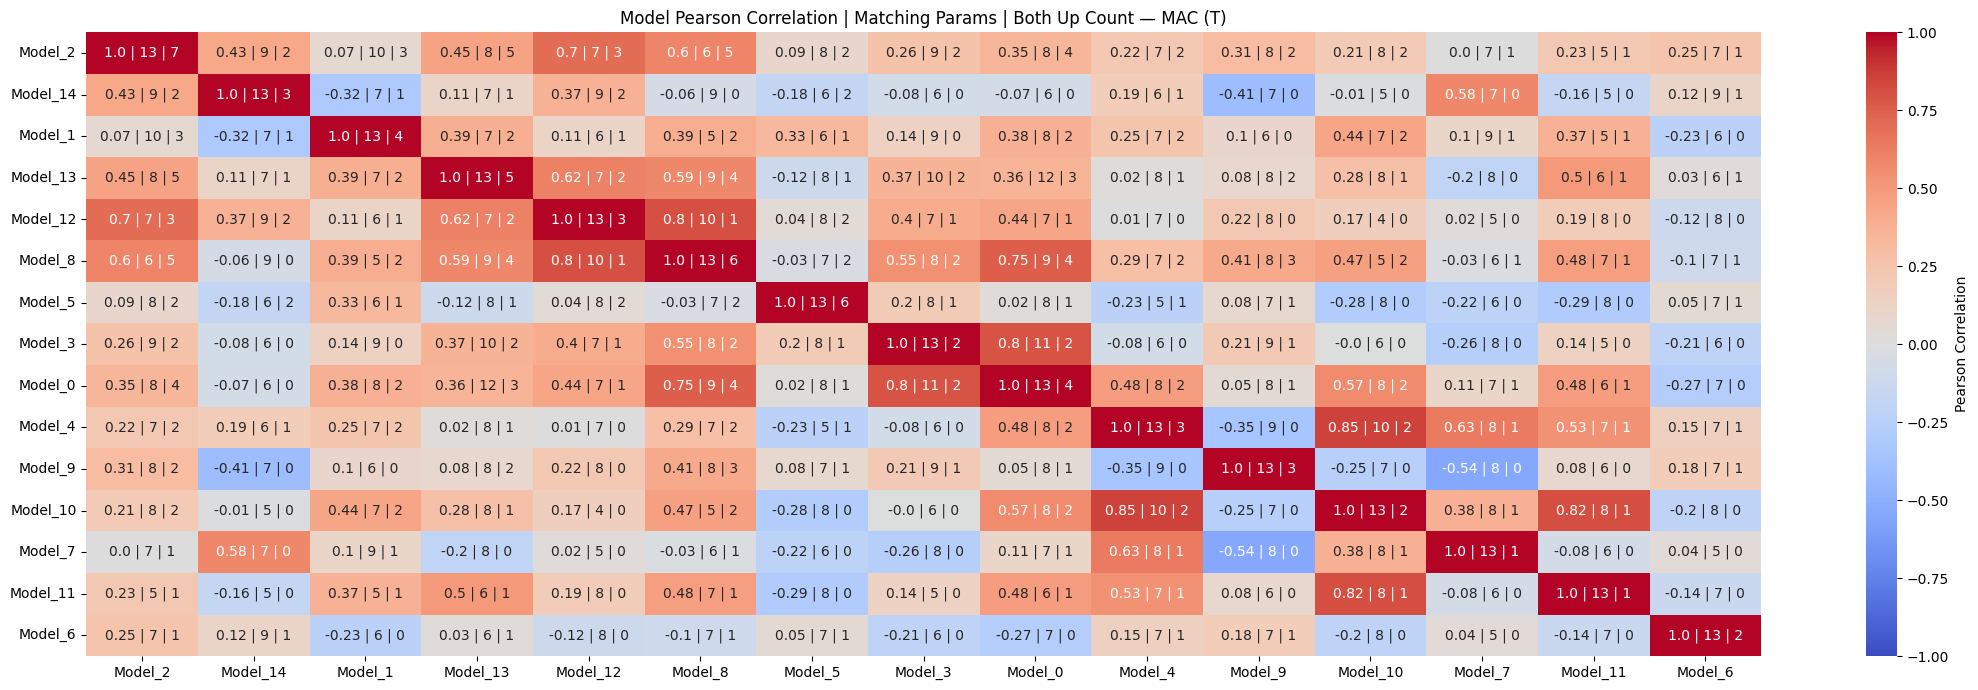

Common pairs: 105  |  Missing in V: 0  |  Missing in T: 0
Diff stats (T - V): mean=0.133, median=0.000, std=1.295, min=-3, max=4


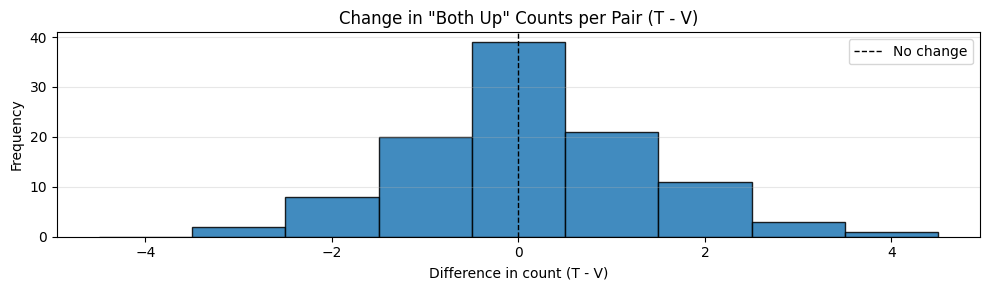

Models Selected : 64
Total seeds selected : 1496
-----
98


In [222]:

RR = {   
                             "mean_precision_range" : (5, 100),"max_zero_precision_seeds" : 70,
                             "max_FP_severe_ratio_FPs" : None, "min_FP_severe_ratio_FPs" : None,         
                             "min_ratio_difference" : None, "max_ratio_difference" : None,

                             "seed_precision_range" : (0, 30) , 
                             "seed_min_TPminusFP_greaterEqual" : None , 
                             "max_seed_severe_FPs_high_bracket" : None , 
                             "min_seed_TPs_high_bracket" : None ,

                             "seed_recall_range" : (0, 100), "min_seeds_per_model" : 1,
                             "max_models_to_return" : 70, "max_FP_severe_ratio_FPs_andTPs" : None, 
                             "min_FP_severe_ratio_FPs_andTPs" : None ,"random_seed" : None 

                               }

models = select_models_by_criteria(results_dist_disc, **RR)

res = collect_V_T_set_FULLraw_data(models, results_dist_disc, results_dist_disc_Tset_same_seeds_organized)
V = res["V_set_data"] ; T = res["T_set_data"]
print(len(V)) ; print(len(T))

res_mac_val = V
res_mac_val = T

# Add threshold metrics
names_all = [V, T]
names_test = [T]
names_val = [V]

for data in names_all:
    add_threshold_metrics(data, threshold=.7)

# Create DataFrames
df_mac_val = flatten_results(V)
df_mac_test = flatten_results(T)

dfs = [df_mac_val, df_mac_test]

# Add various metrics
add_up_prediction_counts(dfs)
add_false_correct_up_stats(dfs)
flatten_metrics_columns(dfs)

master_df = process_parameters_and_merge(dfs)


corr_res_V = plot_model_corr(master_df, machine="mac", set_type="V", use_spearman=False, use_01_preds=False)
corr_res_T = plot_model_corr(master_df, machine="mac", set_type="T", use_spearman=False, use_01_preds=False)





# ---------- Compare "both up" counts between V and T for the SAME model pairs ----------
# corr_res_V / corr_res_T: dict[(id1,id2)] -> (same_params, correlation, both_up_count)

# 1) Align pairs (intersection only)
pairs_V = set(corr_res_V.keys())
pairs_T = set(corr_res_T.keys())
common_pairs = sorted(pairs_V & pairs_T)   # ensure deterministic order

# 2) Build lists of counts (V, T) and differences (T - V)
both_up_V = []
both_up_T = []
pair_labels = []  # optional: keep which pair each diff belongs to

for pair in common_pairs:
    v_both_up = corr_res_V[pair][2]
    t_both_up = corr_res_T[pair][2]
    # safety: ensure ints
    v_both_up = int(v_both_up) if v_both_up is not None else 0
    t_both_up = int(t_both_up) if t_both_up is not None else 0
    both_up_V.append(v_both_up)
    both_up_T.append(t_both_up)
    pair_labels.append(pair)

both_up_V = np.asarray(both_up_V, dtype=int)
both_up_T = np.asarray(both_up_T, dtype=int)
diff_T_minus_V = both_up_T - both_up_V

print(f"Common pairs: {len(common_pairs)}  |  Missing in V: {len(pairs_T - pairs_V)}  |  Missing in T: {len(pairs_V - pairs_T)}")
print(f"Diff stats (T - V): mean={diff_T_minus_V.mean():.3f}, median={np.median(diff_T_minus_V):.3f}, "
      f"std={diff_T_minus_V.std(ddof=0):.3f}, min={diff_T_minus_V.min()}, max={diff_T_minus_V.max()}")

# 3) Plot distribution of differences (T - V)
plt.figure(figsize=(10, 3))
# choose symmetric bins around zero for visual balance
rng = max(1, int(np.ceil(np.max(np.abs(diff_T_minus_V)))))  # at least 1
bins = np.arange(-rng - 0.5, rng + 1.5, 1)  # integer-centered bins

plt.hist(diff_T_minus_V, bins=bins, alpha=0.85, edgecolor='black')
plt.axvline(0, color='k', linestyle='--', linewidth=1, label='No change')
plt.title('Change in "Both Up" Counts per Pair (T - V)')
plt.xlabel('Difference in count (T - V)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()



print(f"Models Selected : {len(models)}")
total_seeds = sum(len(model["selected_seeds"]) for model in models)
print(f"Total seeds selected : {total_seeds}")
print("-" * 5)
total_abs_diff = int(np.abs(diff_T_minus_V).sum())

print(total_abs_diff)




In [144]:
RR

{'mean_precision_range': (5, 100),
 'max_zero_precision_seeds': 70,
 'max_FP_severe_ratio_FPs': None,
 'min_FP_severe_ratio_FPs': None,
 'min_ratio_difference': None,
 'max_ratio_difference': None,
 'seed_precision_range': (80, 100),
 'seed_min_TPminusFP_greaterEqual': None,
 'max_seed_severe_FPs_high_bracket': None,
 'min_seed_TPs_high_bracket': None,
 'seed_recall_range': (0, 30),
 'min_seeds_per_model': 1,
 'max_models_to_return': 70,
 'max_FP_severe_ratio_FPs_andTPs': None,
 'min_FP_severe_ratio_FPs_andTPs': None,
 'random_seed': None}

In [223]:
#####                               Correlation Assessment 


import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

def plot_model_corr(master_df, machine="mac", set_type="V", use_spearman=True, use_01_preds=False):
    """
    Plots correlation and matching-parameter counts for models
    from a given machine ('mac' or 'gc') and set type ('V' or 'T'),
    using the param_int_Vue column as the unique model ID.
    
    Returns: Dictionary with keys as model pairs (tuple) and values as (same_params_count, correlation, both_up_count)
    """
    # Dynamic column names
    preds_col  = f"all_preds_{machine}_{set_type}"
    params_col = f"parameters_{machine}_{set_type}"
    id_col     = f"param_int_Vue_{machine}_{set_type}"  # unique model integer

    # Extract relevant rows
    block = master_df[[preds_col, params_col, id_col]].reset_index(drop=True)
    if block.empty:
        raise ValueError(f"No data found for machine '{machine}' and set '{set_type}'.")

    # 1. Flatten predictions and get model IDs
    all_preds_list = []
    model_ids = []
    
    for idx, preds in enumerate(block[preds_col]):
        flat = [p for fold in preds for p in fold]  # flatten folds
        if use_01_preds:
            flat = [1 if p >= 0.5 else -1 for p in flat]  # binary conversion
        all_preds_list.append(flat)
        model_ids.append(int(block.iloc[idx][id_col]))

    labels = [f"Model_{mid}" for mid in model_ids]
    n_models = len(all_preds_list)
    n_samples = len(all_preds_list[0])  # number of predictions per model

    # 2. Correlation matrix - unified approach
    corr = np.zeros((n_models, n_models))
    both_up_counts = np.zeros((n_models, n_models), dtype=int)  # New: count of both predicting up
    
    for i in range(n_models):
        for j in range(n_models):
            if i <= j:  # Calculate only once for each pair
                # Correlation
                if use_spearman:
                    rho, _ = spearmanr(all_preds_list[i], all_preds_list[j])
                else:
                    rho = np.corrcoef(all_preds_list[i], all_preds_list[j])[0, 1]
                corr[i, j] = rho
                corr[j, i] = rho  # Symmetric matrix
                
                # Count both predicting up (>=0.5) at the same time
                if not use_01_preds:
                    # Convert to binary for counting both up (only if not already in 0/1 form)
                    preds_i_bin = [1 if p >= 0.5 else 0 for p in all_preds_list[i]]
                    preds_j_bin = [1 if p >= 0.5 else 0 for p in all_preds_list[j]]
                else:
                    # Already in binary form: 1 for up, -1 for down (so convert -1 to 0)
                    preds_i_bin = [1 if p == 1 else 0 for p in all_preds_list[i]]
                    preds_j_bin = [1 if p == 1 else 0 for p in all_preds_list[j]]
                
                count_both_up = sum((a == 1) and (b == 1) for a, b in zip(preds_i_bin, preds_j_bin))
                both_up_counts[i, j] = count_both_up
                both_up_counts[j, i] = count_both_up  # Symmetric

    corr_df = pd.DataFrame(corr, index=labels, columns=labels)
    both_up_df = pd.DataFrame(both_up_counts, index=labels, columns=labels)  # DataFrame for both_up counts

    # 3. Matching parameter counts
    keys_to_check = [
        "learning_rate", "num_epochs", "batch_size", "lag",
        "num_layers", "input_size", "use_rolling_fixed_train_size",
        "hidden_size", "use_class_weighting", "use_dropout", 
        "use_custom_loss_function_BCE_THRESH", "train_start_month", "seed"
    ]
    params_list = block[params_col].tolist()
    match_counts = np.zeros((n_models, n_models), dtype=int)

    for i in range(n_models):
        for j in range(n_models):
            p1, p2 = params_list[i], params_list[j]
            if not isinstance(p1, dict) or not isinstance(p2, dict):
                continue
            match_counts[i, j] = sum(p1.get(k) == p2.get(k) for k in keys_to_check)

    match_df = pd.DataFrame(match_counts, index=labels, columns=labels)

    # 4. Annotated heatmap: now with three metrics
    annot = corr_df.round(2).astype(str) + " | " + match_df.astype(str) + " | " + both_up_df.astype(str)
    
    correlation_type = "Spearman" if use_spearman else "Pearson"
    
    plt.figure(figsize=(22, 7))
    sns.heatmap(
        corr_df,
        annot=annot,
        fmt="",
        cmap="coolwarm",
        vmin=-1, vmax=1,
        cbar_kws={'label': f'{correlation_type} Correlation'}
    )
    plt.title(f"Model {correlation_type} Correlation | Matching Params | Both Up Count — {machine.upper()} ({set_type})")
    plt.tight_layout()
    plt.show()

    # 5. Create return data: dictionary with keys as model pairs and values as (same_params, correlation, both_up_count)
    return_data = {}
    for i in range(n_models):
        for j in range(i + 1, n_models):  # Only unique pairs, avoid self-comparisons and duplicates
            model_pair = (model_ids[i], model_ids[j])
            same_params = match_counts[i, j]
            correlation = corr[i, j]
            both_up = both_up_counts[i, j]
            return_data[model_pair] = (same_params, correlation, both_up)

    return return_data




---
# Model Dist 
---

In [224]:
from Functions_1_Initial_GS_and_Dist_Analytics_HOD_20_01_21_12 import *

Number of models with mean precision of 0: 0


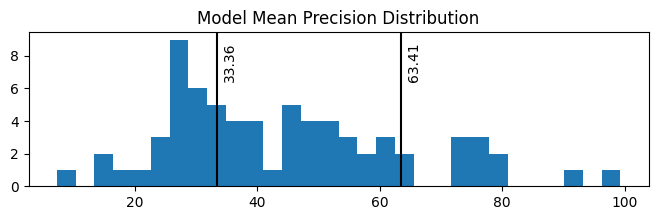

Number of models with mean recall up of 0: 0


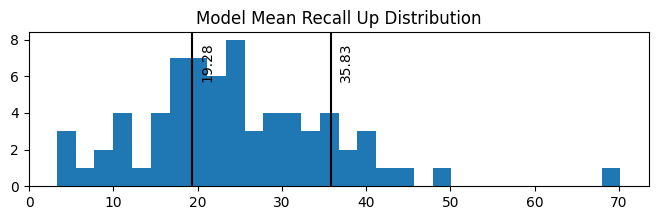

Number of models with ratio difference of 0: 0


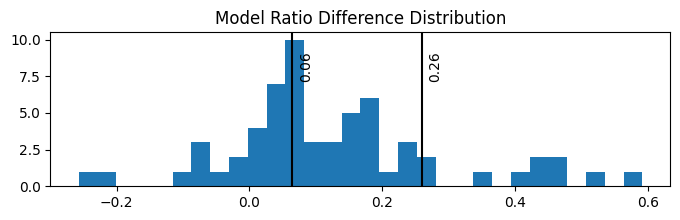

Number of models with FP Severe Ratio FPs of 0: 4


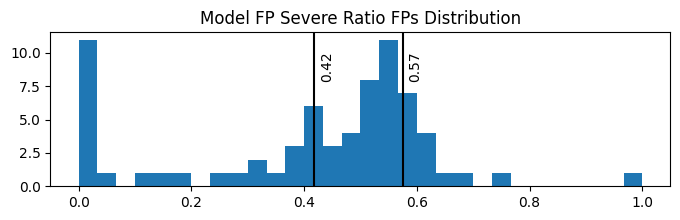

Number of models with FP Severe Ratio FPs and TPs of 0: 4


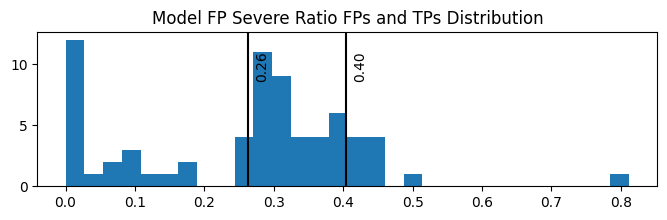

Number of seeds with precision of 0: 685


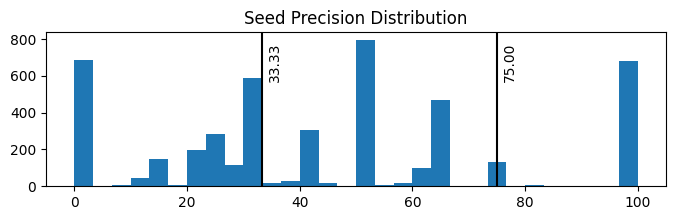

Number of seeds with recall of 0: 685


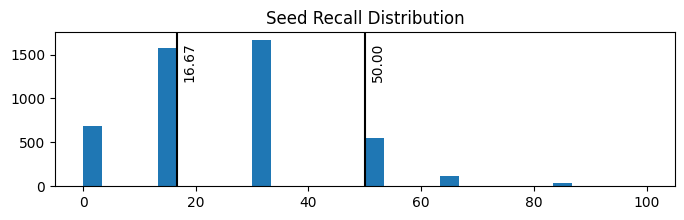

Number of seeds with TP minus FP of 0: 804


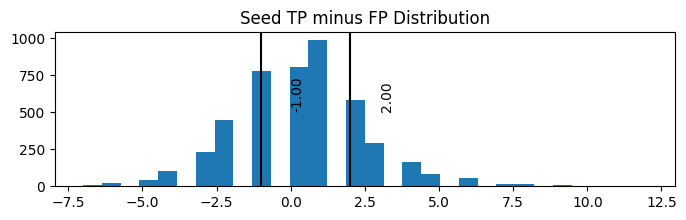

Number of seeds with severe FP high bracket of 0: 3190


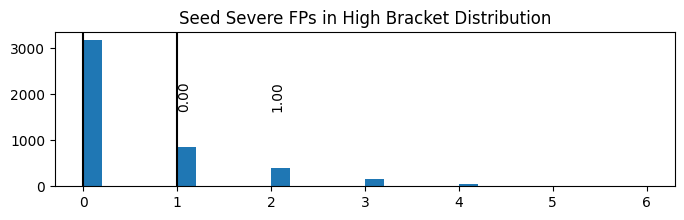

Number of seeds with TP high bracket of 0: 657


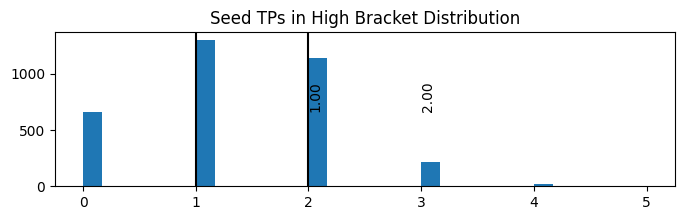

In [225]:
######             Plot the Dist for each variable metric, choose high, mid and low based on PERCENTILE RANGES
# this is better for standardizing across different data sets and time periods


selected_models = select_models_by_criteria(
    results_data=results_dist_disc,
    mean_precision_range=(0, 100),
    mean_recall_up_range=(0, 100),
    seed_precision_range=(0, 100),
    seed_recall_range=(0, 100),
    min_seeds_per_model=1,
    max_models_to_return=len(results_dist_disc),  # include all; prevents sampling cap
    max_zero_precision_seeds=None,
    min_ratio_difference=None,
    max_ratio_difference=None,
    seed_min_TPminusFP_greaterEqual=None,
    max_FP_severe_ratio_FPs=None,
    max_FP_severe_ratio_FPs_andTPs=None,
    min_FP_severe_ratio_FPs=None,
    min_FP_severe_ratio_FPs_andTPs=None,
    max_seed_severe_FPs_high_bracket=None,
    min_seed_TPs_high_bracket=None,
    random_seed=None,
)

###########                 MODEL METRICS DISTS

# mean_precison
plt.figure(figsize=(8, 2))
mean_precision_list = [model['mean_precision'] for model in selected_models]
zero_count = sum(1 for mp in mean_precision_list if mp == 0)
print(f'Number of models with mean precision of 0: {zero_count}')
Mp_1q = np.percentile(mean_precision_list, 35)
Mp_2q = np.percentile(mean_precision_list, 85)
plt.hist(mean_precision_list, bins=30)

ax = plt.gca()              
x_min, x_max = ax.get_xlim() ; y_min, y_max = ax.get_ylim()

plt.text(Mp_1q + 1, y_max * 0.7, f'{Mp_1q:.2f}', rotation=90)
plt.text(Mp_2q + 1, y_max * 0.7, f'{Mp_2q:.2f}', rotation=90)
plt.axvline(x=Mp_1q, color='k')
plt.axvline(x=Mp_2q, color='k')
plt.title('Model Mean Precision Distribution')
plt.show()

# mean_recall_up
plt.figure(figsize=(8, 2))
mean_recall_up_list = [model['mean_recall_up'] for model in selected_models]
zero_count = sum(1 for mr in mean_recall_up_list if mr == 0)
print(f'Number of models with mean recall up of 0: {zero_count}')
Mr_1q = np.percentile(mean_recall_up_list, 35)
Mr_2q = np.percentile(mean_recall_up_list, 85)
plt.hist(mean_recall_up_list, bins=30)

ax = plt.gca()
x_min, x_max = ax.get_xlim() ; y_min, y_max = ax.get_ylim()
plt.text(Mr_1q + 1, y_max * 0.7, f'{Mr_1q:.2f}', rotation=90)
plt.text(Mr_2q + 1, y_max * 0.7, f'{Mr_2q:.2f}', rotation=90)
plt.axvline(x=Mr_1q, color='k')
plt.axvline(x=Mr_2q, color='k')
plt.title('Model Mean Recall Up Distribution')
plt.show()

# ratio_difference
plt.figure(figsize=(8, 2))
ratio_difference_list = [model['ratio_difference'] for model in selected_models if model['ratio_difference'] is not None]
zero_count = sum(1 for rd in ratio_difference_list if rd == 0)
print(f'Number of models with ratio difference of 0: {zero_count}')
Rd_1q = np.percentile(ratio_difference_list, 35)
Rd_2q = np.percentile(ratio_difference_list, 85)
plt.hist(ratio_difference_list, bins=30)
ax = plt.gca()              
x_min, x_max = ax.get_xlim() ; y_min, y_max = ax.get_ylim()
plt.text(Rd_1q + 0.01, y_max * 0.7, f'{Rd_1q:.2f}', rotation=90)
plt.text(Rd_2q + 0.01, y_max * 0.7, f'{Rd_2q:.2f}', rotation=90)
plt.axvline(x=Rd_1q, color='k')
plt.axvline(x=Rd_2q, color='k')
plt.title('Model Ratio Difference Distribution')
plt.show()

# fp_severe_ratio_fps
plt.figure(figsize=(8, 2))
fp_severe_ratio_fps_list = [model['fp_severe_ratio_fps'] for model in selected_models if model['fp_severe_ratio_fps'] is not None]
zero_count = sum(1 for fpr in fp_severe_ratio_fps_list if fpr == 0)
print(f'Number of models with FP Severe Ratio FPs of 0: {zero_count}')
Fpr_Fps_1q = np.percentile(fp_severe_ratio_fps_list, 35)
Fpr_Fps_2q = np.percentile(fp_severe_ratio_fps_list, 85)
plt.hist(fp_severe_ratio_fps_list, bins=30)
ax = plt.gca()              
x_min, x_max = ax.get_xlim() ; y_min, y_max = ax.get_ylim()
plt.text(Fpr_Fps_1q + 0.01, 0.7 * y_max, f'{Fpr_Fps_1q:.2f}', rotation=90)
plt.text(Fpr_Fps_2q + 0.01, 0.7 * y_max, f'{Fpr_Fps_2q:.2f}', rotation=90)
plt.axvline(x=Fpr_Fps_1q, color='k')
plt.axvline(x=Fpr_Fps_2q, color='k')
plt.title('Model FP Severe Ratio FPs Distribution')
plt.show()

# fp_severe_ratio_fps_tps
plt.figure(figsize=(8, 2))
fp_severe_ratio_fps_tps_list = [model['fp_severe_ratio_fps_tps'] for model in selected_models if model['fp_severe_ratio_fps_tps'] is not None]
zero_count = sum(1 for fpr in fp_severe_ratio_fps_tps_list if fpr == 0)
print(f'Number of models with FP Severe Ratio FPs and TPs of 0: {zero_count}')
Fpr_Fps_Tps_1q = np.percentile(fp_severe_ratio_fps_tps_list, 35)
Fpr_Fps_Tps_2q = np.percentile(fp_severe_ratio_fps_tps_list, 85)
plt.hist(fp_severe_ratio_fps_tps_list, bins=30)
ax = plt.gca()              
x_min, x_max = ax.get_xlim() ; y_min, y_max = ax.get_ylim()
plt.text(Fpr_Fps_Tps_1q + 0.01, 0.7 * y_max, f'{Fpr_Fps_Tps_1q:.2f}', rotation=90)
plt.text(Fpr_Fps_Tps_2q + 0.01, 0.7 * y_max, f'{Fpr_Fps_Tps_2q:.2f}', rotation=90)
plt.axvline(x=Fpr_Fps_Tps_1q, color='k')
plt.axvline(x=Fpr_Fps_Tps_2q, color='k')
plt.title('Model FP Severe Ratio FPs and TPs Distribution')
plt.show()

###########                 SEED METRICS DISTS

# seed_precision
plt.figure(figsize=(8, 2))
all_seed_precisions = []
for model in selected_models:
    for seed_result in model['selected_seeds']:
        all_seed_precisions.append(seed_result['precision'])
sp_1q = np.percentile(all_seed_precisions, 35)
sp_2q = np.percentile(all_seed_precisions, 85)
zero_count = sum(1 for sp in all_seed_precisions if sp == 0)
print(f'Number of seeds with precision of 0: {zero_count}')

plt.hist(all_seed_precisions, bins=30)
ax = plt.gca()              
x_min, x_max = ax.get_xlim() ; y_min, y_max = ax.get_ylim()
plt.text(sp_1q + 1, 0.7 * y_max, f'{sp_1q:.2f}', rotation=90)
plt.text(sp_2q + 1, 0.7 * y_max, f'{sp_2q:.2f}', rotation=90)
plt.axvline(x=sp_1q, color='k')
plt.axvline(x=sp_2q, color='k')
plt.title('Seed Precision Distribution')
plt.show()

# seed_recall
all_seed_recalls = []
for model in selected_models:
    for seed_result in model['selected_seeds']:
        all_seed_recalls.append(seed_result['recall'])
zero_count = sum(1 for sr in all_seed_recalls if sr == 0)
print(f'Number of seeds with recall of 0: {zero_count}')
sr_1q = np.percentile(all_seed_recalls, 35)
sr_2q = np.percentile(all_seed_recalls, 85)

plt.figure(figsize=(8, 2))
plt.hist(all_seed_recalls, bins=30)
ax = plt.gca()              
x_min, x_max = ax.get_xlim() ; y_min, y_max = ax.get_ylim()
plt.text(sr_1q + 1, 0.7 * y_max, f'{sr_1q:.2f}', rotation=90)
plt.text(sr_2q + 1, 0.7 * y_max, f'{sr_2q:.2f}', rotation=90)
plt.axvline(x=sr_1q, color='k')
plt.axvline(x=sr_2q, color='k')
plt.title('Seed Recall Distribution')
plt.show()


# seed_min_TPminusFP_greaterEqual

all_seed_TPminusFP=[]
for model in selected_models:
    for seed_result in model['selected_seeds']:

        bracket_high = seed_result["seed_bracket_counts"].get("0.7-1.0", {"TP": 0, "FP": 0})
        bracket_low = seed_result["seed_bracket_counts"].get("0.5-0.7", {"TP": 0, "FP": 0})

        net_high = bracket_high["TP"] - bracket_high["FP"]
        net_low = bracket_low["TP"] - bracket_low["FP"]
        TPminusFP = net_high - net_low
        all_seed_TPminusFP.append(TPminusFP)

zero_count = sum(1 for st in all_seed_TPminusFP if st == 0)
print(f'Number of seeds with TP minus FP of 0: {zero_count}')
s_TPminusFP_1q = np.percentile(all_seed_TPminusFP, 35)
s_TPminusFP_2q = np.percentile(all_seed_TPminusFP, 85)

plt.figure(figsize=(8, 2))
plt.hist(all_seed_TPminusFP, bins=30)

ax = plt.gca()              
x_min, x_max = ax.get_xlim() ; y_min, y_max = ax.get_ylim()
plt.text(s_TPminusFP_1q + 1, .5 * y_max, f'{s_TPminusFP_1q:.2f}', rotation=90)
plt.text(s_TPminusFP_2q + 1, .5 * y_max, f'{s_TPminusFP_2q:.2f}', rotation=90)
plt.axvline(x=s_TPminusFP_1q, color='k')
plt.axvline(x=s_TPminusFP_2q, color='k')
plt.title('Seed TP minus FP Distribution')
plt.show()


# max_seed_severe_FPs_high_bracket
all_seed_severe_FPs_high_bracket = []
for model in selected_models:
    for seed_result in model['selected_seeds']:
        all_seed_severe_FPs_high_bracket.append(seed_result['seed_severe_fp_high_bracket'])
zero_count = sum(1 for sr in all_seed_severe_FPs_high_bracket if sr == 0)
print(f'Number of seeds with severe FP high bracket of 0: {zero_count}')

s_severeFPs_H_1q = np.percentile(all_seed_severe_FPs_high_bracket, 35)
s_severeFPs_H_2q = np.percentile(all_seed_severe_FPs_high_bracket, 85)

plt.figure(figsize=(8, 2))
plt.hist(all_seed_severe_FPs_high_bracket, bins=30)

ax = plt.gca()              
x_min, x_max = ax.get_xlim() ; y_min, y_max = ax.get_ylim()

plt.text(s_severeFPs_H_1q + 1, .5 * y_max, f'{s_severeFPs_H_1q:.2f}', rotation=90)
plt.text(s_severeFPs_H_2q + 1, .5 * y_max, f'{s_severeFPs_H_2q:.2f}', rotation=90)
plt.axvline(x=s_severeFPs_H_1q, color='k')
plt.axvline(x=s_severeFPs_H_2q, color='k')
plt.title('Seed Severe FPs in High Bracket Distribution')
plt.show()

# min_seed_TPs_high_bracket

all_seed_TPs_high_bracket = []

for model in selected_models:
    for seed_result in model['selected_seeds']:
        if "0.7-1.0" in seed_result['seed_bracket_counts']:

            all_seed_TPs_high_bracket.append(seed_result['seed_bracket_counts']["0.7-1.0"]["TP"])

zero_count = sum(1 for st in all_seed_TPs_high_bracket if st == 0)
print(f'Number of seeds with TP high bracket of 0: {zero_count}')
s_TPs_H_1q = np.percentile(all_seed_TPs_high_bracket, 35)
s_TPs_H_2q = np.percentile(all_seed_TPs_high_bracket, 85)

plt.figure(figsize=(8, 2))
plt.hist(all_seed_TPs_high_bracket, bins=30)
ax = plt.gca()              
x_min, x_max = ax.get_xlim() ; y_min, y_max = ax.get_ylim()
plt.text(s_TPs_H_1q + 1, .5 * y_max, f'{s_TPs_H_1q:.2f}', rotation=90)
plt.text(s_TPs_H_2q + 1, .5 * y_max, f'{s_TPs_H_2q:.2f}', rotation=90)
plt.axvline(x=s_TPs_H_1q, color='k')
plt.axvline(x=s_TPs_H_2q, color='k')
plt.title('Seed TPs in High Bracket Distribution')
plt.show()


In [247]:
### NOTE consider changing this os that the function chooses the max number of midels possible , this should imporve the resutls in general since 
### seeds of the same model are generally more correalted --- this can also be tested but i am pretty positive this is the case (ran short tests)

### NOTE for now since we want to test the params for model slection , it may be better to keep it as is for standardization

def collect_V_T_set_FULLraw_data(models_selected, results_dist_disc, results_dist_disc_Tset_same_seeds_organized):
    T_set_data = [] 
    V_set_data = []

    # select 5 models at random from the selected models
    models_RAND = random.sample(models_selected, min(15, len(models_selected)))

    for model_entry in models_RAND:
        model_seeds = []
        ff_combo_idx = model_entry['combo_index']
        for seed_entry in model_entry['selected_seeds']:
            seed_num = seed_entry['seed_num']
            model_seeds.append(seed_num)

        ##### Find randomly chosen seeds in the V and T raw data 
        for raw_data_entry_V in results_dist_disc:
            V_combo_idx = raw_data_entry_V["combo_index"]
            if ff_combo_idx == V_combo_idx:
                rand_chosen_seeds = random.sample(model_seeds, min(1, len(model_seeds)))
                for seed_chosen in rand_chosen_seeds:
                    for seed_raw in raw_data_entry_V['per_seed_all_results']:
                        if seed_raw['seed'] == seed_chosen:
                            V_set_data.append(seed_raw['result_entry'])

        for raw_data_entry_T in results_dist_disc_Tset_same_seeds_organized:
            T_combo_idx = raw_data_entry_T["combo_index"]
            if ff_combo_idx == T_combo_idx:
                for seed_chosen in rand_chosen_seeds:
                    for seed_raw in raw_data_entry_T['per_seed_all_results']:
                        if seed_raw['seed'] == seed_chosen:
                            T_set_data.append(seed_raw['result_entry'])

    return {"V_set_data": V_set_data, "T_set_data": T_set_data}


                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

# res = collect_V_T_set_FULLraw_data(Mp_H__param_map_models, results_dist_disc, results_dist_disc_Tset_same_seeds_organized)
# V_set_data = res["V_set_data"] ; T_set_data = res["T_set_data"]
# print(len(V_set_data)) ; print(len(T_set_data))  


In [248]:

####                                   Model Selection (seeds chosen at random)

# params to analyze - mean_precision_range , min_ratio_difference , max_FP_severe_ratio_FPs


Mp_H__param_map = {   # params to analyze
                             "mean_precision_range" : (75, 100),
                             "max_zero_precision_seeds" : 70,
                             "mean_recall_up_range" : (0, 100), "seed_recall_range" : (0, 100),

                             # params ignored 
                             "min_ratio_difference" : None, "max_ratio_difference" : None,
                             "max_FP_severe_ratio_FPs" : None, "min_FP_severe_ratio_FPs" : None,
                             "seed_precision_range" : (0, 100), "min_seeds_per_model" : 1,"max_models_to_return" : 70, "seed_min_TPminusFP_greaterEqual" : None,"max_FP_severe_ratio_FPs_andTPs" : None, 
                             "max_seed_severe_FPs_high_bracket" : None,"min_seed_TPs_high_bracket" : None, "random_seed" : None , "min_FP_severe_ratio_FPs_andTPs" : None                                  
                               }

Mp_M__param_map = {   
                             "mean_precision_range" : (40, 75),
                             "max_zero_precision_seeds" : 70,
                             "mean_recall_up_range" : (0, 100), "seed_recall_range" : (0, 100),

                             "min_ratio_difference" : None, "max_ratio_difference" : None,
                             "max_FP_severe_ratio_FPs" : None, "min_FP_severe_ratio_FPs" : None,
                             "seed_precision_range" : (0, 100), "min_seeds_per_model" : 1,"max_models_to_return" : 70, "seed_min_TPminusFP_greaterEqual" : None,"max_FP_severe_ratio_FPs_andTPs" : None, 
                             "max_seed_severe_FPs_high_bracket" : None,"min_seed_TPs_high_bracket" : None, "random_seed" : None , "min_FP_severe_ratio_FPs_andTPs" : None
                               }

Mp_L__param_map = {   
                             "mean_precision_range" : (5, 40),
                             "max_zero_precision_seeds" : 70,
                             "min_ratio_difference" : None, "max_ratio_difference" : None,
                             "max_FP_severe_ratio_FPs" : None, "min_FP_severe_ratio_FPs" : None,
                             "mean_recall_up_range" : (0, 100), "seed_recall_range" : (0, 100),

                             "seed_precision_range" : (0, 100), "min_seeds_per_model" : 1,"max_models_to_return" : 70, "seed_min_TPminusFP_greaterEqual" : None,"max_FP_severe_ratio_FPs_andTPs" : None, 
                             "max_seed_severe_FPs_high_bracket" : None,"min_seed_TPs_high_bracket" : None, "random_seed" : None , "min_FP_severe_ratio_FPs_andTPs" : None
                               }

#############

DES_Mp_ALL__Rfps_H__param_map = {   # params to analyze
                             "mean_precision_range" : (5, 100),
                             "max_zero_precision_seeds" : 70,
                             "max_FP_severe_ratio_FPs" : 0.4, "min_FP_severe_ratio_FPs" : None,
                             "mean_recall_up_range" : (0, 100), "seed_recall_range" : (0, 100),
                             # params ignored 
                             "min_ratio_difference" : None, "max_ratio_difference" : None,
                             "seed_precision_range" : (0, 100), "min_seeds_per_model" : 1,"max_models_to_return" : 70, "seed_min_TPminusFP_greaterEqual" : None,"max_FP_severe_ratio_FPs_andTPs" : None, 
                             "max_seed_severe_FPs_high_bracket" : None,"min_seed_TPs_high_bracket" : None, "random_seed" : None , "min_FP_severe_ratio_FPs_andTPs" : None
                               }


DES_Mp_ALL__Rfps_L__param_map = {   # params to analyze
                             "mean_precision_range" : (5, 100),
                             "max_zero_precision_seeds" : 70,
                             "max_FP_severe_ratio_FPs" : 0.2, "min_FP_severe_ratio_FPs" : None,
                             "mean_recall_up_range" : (0, 100), "seed_recall_range" : (0, 100),
                             # params ignored 
                             "min_ratio_difference" : None, "max_ratio_difference" : None,
                             "seed_precision_range" : (1, 40),  "min_seeds_per_model" : 1,"max_models_to_return" : 70, "seed_min_TPminusFP_greaterEqual" : None,"max_FP_severe_ratio_FPs_andTPs" : None, 
                             "max_seed_severe_FPs_high_bracket" : None,"min_seed_TPs_high_bracket" : None, "random_seed" : None , "min_FP_severe_ratio_FPs_andTPs" : None
                               }


unDES_Mp_ALL__Rfps_H__param_map = {   
                             "mean_precision_range" : (5, 100),
                             "max_zero_precision_seeds" : 70,
                             "max_FP_severe_ratio_FPs" : 0.7, "min_FP_severe_ratio_FPs" : .5,         
                             "mean_recall_up_range" : (0, 100), "seed_recall_range" : (0, 100),
                             "min_ratio_difference" : None, "max_ratio_difference" : None,
                             "seed_precision_range" : (0, 100),  "min_seeds_per_model" : 1,"max_models_to_return" : 70, "seed_min_TPminusFP_greaterEqual" : None,"max_FP_severe_ratio_FPs_andTPs" : None, 
                             "max_seed_severe_FPs_high_bracket" : None,"min_seed_TPs_high_bracket" : None, "random_seed" : None , "min_FP_severe_ratio_FPs_andTPs" : None
                               }

### 
DES_Mp_ALL__R_L__param_map = {   
                             "mean_precision_range" : (5, 100),
                             "max_zero_precision_seeds" : 70,
                             "max_FP_severe_ratio_FPs" : None, "min_FP_severe_ratio_FPs" : None,
                             "mean_recall_up_range" : (0, 100), "seed_recall_range" : (0, 100),

                             "min_ratio_difference" : 0.1, "max_ratio_difference" : .3,
                             "seed_precision_range" : (0, 100),  "min_seeds_per_model" : 1,"max_models_to_return" : 70, "seed_min_TPminusFP_greaterEqual" : None,"max_FP_severe_ratio_FPs_andTPs" : None, 
                             "max_seed_severe_FPs_high_bracket" : None,"min_seed_TPs_high_bracket" : None, "random_seed" : None , "min_FP_severe_ratio_FPs_andTPs" : None
                               }


DES_Mp_ALL__R_H__param_map = {  
                             "mean_precision_range" : (5, 100),
                             "max_zero_precision_seeds" : 70,
                             "max_FP_severe_ratio_FPs" : None, "min_FP_severe_ratio_FPs" : None,
                             "mean_recall_up_range" : (0, 100), "seed_recall_range" : (0, 100),

                             "min_ratio_difference" : .3, "max_ratio_difference" : None ,
                             "seed_precision_range" : (0, 100),  "min_seeds_per_model" : 1,"max_models_to_return" : 70, "seed_min_TPminusFP_greaterEqual" : None,"max_FP_severe_ratio_FPs_andTPs" : None, 
                             "max_seed_severe_FPs_high_bracket" : None,"min_seed_TPs_high_bracket" : None, "random_seed" : None , "min_FP_severe_ratio_FPs_andTPs" : None
                               }

unDES_Mp_ALL__R_neg__param_map = {   
                             "mean_precision_range" : (5, 100),
                             "max_zero_precision_seeds" : 70,
                             "max_FP_severe_ratio_FPs" : None, "min_FP_severe_ratio_FPs" : None,         
                             "mean_recall_up_range" : (0, 100), "seed_recall_range" : (0, 100),
                             "min_ratio_difference" : None, "max_ratio_difference" : 0,
                             "seed_precision_range" : (0, 100), "min_seeds_per_model" : 1,"max_models_to_return" : 70, "seed_min_TPminusFP_greaterEqual" : None,"max_FP_severe_ratio_FPs_andTPs" : None, 
                             "max_seed_severe_FPs_high_bracket" : None,"min_seed_TPs_high_bracket" : None, "random_seed" : None , "min_FP_severe_ratio_FPs_andTPs" : None
                               }

# ###################



Mp_H__param_map_models = select_models_by_criteria(results_dist_disc, **Mp_H__param_map)
Mp_M__param_map_models = select_models_by_criteria(results_dist_disc, **Mp_M__param_map)
Mp_L__param_map_models = select_models_by_criteria(results_dist_disc, **Mp_L__param_map)


DES_Mp_ALL__Rfps_H__param_map_models = select_models_by_criteria(results_dist_disc, **DES_Mp_ALL__Rfps_H__param_map)
DES_Mp_ALL__Rfps_L__param_map_models = select_models_by_criteria(results_dist_disc, **DES_Mp_ALL__Rfps_L__param_map)
unDES_Mp_ALL__Rfps_H__param_map_models = select_models_by_criteria(results_dist_disc, **unDES_Mp_ALL__Rfps_H__param_map)


DES_Mp_ALL__R_L__param_map_models = select_models_by_criteria(results_dist_disc, **DES_Mp_ALL__R_L__param_map)
DES_Mp_ALL__R_H__param_map_models = select_models_by_criteria(results_dist_disc, **DES_Mp_ALL__R_H__param_map)
unDES_Mp_ALL__R_neg__param_map_models = select_models_by_criteria(results_dist_disc, **unDES_Mp_ALL__R_neg__param_map)


models_res_names_dict = { ## print model seleciton info , 
    "DES_Mp_H": Mp_H__param_map_models,
    "DES_Mp_M": Mp_M__param_map_models,
    "DES_Mp_L": Mp_L__param_map_models,

    "DES_Mp_ALL__Rfps_H": DES_Mp_ALL__Rfps_H__param_map_models,
    "DES_Mp_ALL__Rfps_L": DES_Mp_ALL__Rfps_L__param_map_models,
    "unDES_Mp_ALL__Rfps_H": unDES_Mp_ALL__Rfps_H__param_map_models,

    "DES_Mp_ALL__R_L": DES_Mp_ALL__R_L__param_map_models,
    "DES_Mp_ALL__R_H": DES_Mp_ALL__R_H__param_map_models,
    "unDES_Mp_ALL__R_neg": unDES_Mp_ALL__R_neg__param_map_models

}   

for k, selected_models in models_res_names_dict.items():
   print(f"Models Selected {k}: {len(selected_models)}")
   total_seeds = sum(len(model["selected_seeds"]) for model in selected_models)
   print(f"Total seeds selected {k}: {total_seeds}")
   print("-" * 5)



#### collect raw V and T set data for the selected models
Mp_H__data_V_T_rawData = collect_V_T_set_FULLraw_data(Mp_H__param_map_models, results_dist_disc, results_dist_disc_Tset_same_seeds_organized)
Mp_M__data_V_T_rawData = collect_V_T_set_FULLraw_data(Mp_M__param_map_models, results_dist_disc, results_dist_disc_Tset_same_seeds_organized)
Mp_L__data_V_T_rawData = collect_V_T_set_FULLraw_data(Mp_L__param_map_models, results_dist_disc, results_dist_disc_Tset_same_seeds_organized)

DES_Mp_ALL__Rfps_H__data_V_T_rawData = collect_V_T_set_FULLraw_data(DES_Mp_ALL__Rfps_H__param_map_models, results_dist_disc, results_dist_disc_Tset_same_seeds_organized)
DES_Mp_ALL__Rfps_L__data_V_T_rawData = collect_V_T_set_FULLraw_data(DES_Mp_ALL__Rfps_L__param_map_models, results_dist_disc, results_dist_disc_Tset_same_seeds_organized)
unDES_Mp_ALL__Rfps_H__data_V_T_rawData = collect_V_T_set_FULLraw_data(unDES_Mp_ALL__Rfps_H__param_map_models, results_dist_disc, results_dist_disc_Tset_same_seeds_organized)

DES_Mp_ALL__R_L__data_V_T_rawData = collect_V_T_set_FULLraw_data(DES_Mp_ALL__R_L__param_map_models, results_dist_disc, results_dist_disc_Tset_same_seeds_organized)
DES_Mp_ALL__R_H__data_V_T_rawData = collect_V_T_set_FULLraw_data(DES_Mp_ALL__R_H__param_map_models, results_dist_disc, results_dist_disc_Tset_same_seeds_organized)
unDES_Mp_ALL__R_neg__data_V_T_rawData = collect_V_T_set_FULLraw_data(unDES_Mp_ALL__R_neg__param_map_models, results_dist_disc, results_dist_disc_Tset_same_seeds_organized) 
#### collect raw V and T set data for the selected models

model_based_selection_maps_raw_V_T_data = {
    "Mp_H": Mp_H__data_V_T_rawData,
    "Mp_M": Mp_M__data_V_T_rawData,
    "Mp_L": Mp_L__data_V_T_rawData,

    "DES_Mp_ALL__Rfps_H": DES_Mp_ALL__Rfps_H__data_V_T_rawData,
    "DES_Mp_ALL__Rfps_L": DES_Mp_ALL__Rfps_L__data_V_T_rawData,
    "unDES_Mp_ALL__Rfps_H": unDES_Mp_ALL__Rfps_H__data_V_T_rawData,

    "DES_Mp_ALL__R_L": DES_Mp_ALL__R_L__data_V_T_rawData,
    "DES_Mp_ALL__R_H": DES_Mp_ALL__R_H__data_V_T_rawData,
    "unDES_Mp_ALL__R_neg": unDES_Mp_ALL__R_neg__data_V_T_rawData
}

import pickle

with open('model_based_selection_maps_raw_V_T_data.pkl', 'wb') as f:
    pickle.dump(model_based_selection_maps_raw_V_T_data, f)


Models Selected DES_Mp_H: 6
Total seeds selected DES_Mp_H: 420
-----
Models Selected DES_Mp_M: 30
Total seeds selected DES_Mp_M: 2040
-----
Models Selected DES_Mp_L: 34
Total seeds selected DES_Mp_L: 2187
-----
Models Selected DES_Mp_ALL__Rfps_H: 23
Total seeds selected DES_Mp_ALL__Rfps_H: 1543
-----
Models Selected DES_Mp_ALL__Rfps_L: 12
Total seeds selected DES_Mp_ALL__Rfps_L: 149
-----
Models Selected unDES_Mp_ALL__Rfps_H: 31
Total seeds selected unDES_Mp_ALL__Rfps_H: 2038
-----
Models Selected DES_Mp_ALL__R_L: 20
Total seeds selected DES_Mp_ALL__R_L: 1378
-----
Models Selected DES_Mp_ALL__R_H: 8
Total seeds selected DES_Mp_ALL__R_H: 538
-----
Models Selected unDES_Mp_ALL__R_neg: 10
Total seeds selected unDES_Mp_ALL__R_neg: 646
-----


In [249]:
####                                   Model Selection (SEED filter only) ---- seed filter only to see if the dist discovery inc the prec 

Sp_H__param_map = {   
                             "mean_precision_range" : (5, 100),"max_zero_precision_seeds" : 70,"max_FP_severe_ratio_FPs" : None, "min_FP_severe_ratio_FPs" : None, "min_ratio_difference" : None, "max_ratio_difference" : None,
                             
                             "seed_precision_range" : (75, 100) , 
                             "mean_recall_up_range" : (0, 100), "seed_recall_range" : (0, 100),
                             "seed_min_TPminusFP_greaterEqual" : None , "max_seed_severe_FPs_high_bracket" : None , "min_seed_TPs_high_bracket" : None ,
                              "min_seeds_per_model" : 1,"max_models_to_return" : 70, "max_FP_severe_ratio_FPs_andTPs" : None, "min_FP_severe_ratio_FPs_andTPs" : None ,"random_seed" : None 

                               }

Sp_M__param_map = {   
                             "mean_precision_range" : (5, 100),"max_zero_precision_seeds" : 70, "max_FP_severe_ratio_FPs" : None, "min_FP_severe_ratio_FPs" : None,"min_ratio_difference" : None, "max_ratio_difference" : None,
                             
                             "seed_precision_range" : (40, 75) , 
                             "mean_recall_up_range" : (0, 100), "seed_recall_range" : (0, 100),
                             "seed_min_TPminusFP_greaterEqual" : None , "max_seed_severe_FPs_high_bracket" : None , 
                             "min_seed_TPs_high_bracket" : None ,
                              "min_seeds_per_model" : 1,"max_models_to_return" : 70, "max_FP_severe_ratio_FPs_andTPs" : None, "min_FP_severe_ratio_FPs_andTPs" : None ,"random_seed" : None 
                               }

Sp_L__param_map = {   
                             "mean_precision_range" : (5, 100),"max_zero_precision_seeds" : 70,"max_FP_severe_ratio_FPs" : None, "min_FP_severe_ratio_FPs" : None, "min_ratio_difference" : None, "max_ratio_difference" : None,

                             "seed_precision_range" : (1, 40) , 
                             "mean_recall_up_range" : (0, 100), "seed_recall_range" : (0, 100),
                             "seed_min_TPminusFP_greaterEqual" : None , "max_seed_severe_FPs_high_bracket" : None , 
                             "min_seed_TPs_high_bracket" : None , 
                              "min_seeds_per_model" : 1,"max_models_to_return" : 70, "max_FP_severe_ratio_FPs_andTPs" : None, "min_FP_severe_ratio_FPs_andTPs" : None ,"random_seed" : None 
                               }

####

DES_TH_Sp_ALL__Hb_0fp1tp__param_map = {   
                             "mean_precision_range" : (5, 100),"max_zero_precision_seeds" : 70,
                             "max_FP_severe_ratio_FPs" : None, "min_FP_severe_ratio_FPs" : None,         
                             "min_ratio_difference" : None, "max_ratio_difference" : None,

                             "seed_precision_range" : (5, 100) , 
                             "seed_min_TPminusFP_greaterEqual" : None , 
                             "max_seed_severe_FPs_high_bracket" : 0 , #**
                             "min_seed_TPs_high_bracket" : 1 , #**
                             "mean_recall_up_range" : (0, 100), "seed_recall_range" : (0, 100),
                              "min_seeds_per_model" : 1,
                             "max_models_to_return" : 70, "max_FP_severe_ratio_FPs_andTPs" : None, 
                             "min_FP_severe_ratio_FPs_andTPs" : None ,"random_seed" : None 

                               }

DES_TH_Sp_ALL__Hb_1fp1tp__param_map = {   
                             "mean_precision_range" : (5, 100),"max_zero_precision_seeds" : 70,
                             "max_FP_severe_ratio_FPs" : None, "min_FP_severe_ratio_FPs" : None,         
                             "min_ratio_difference" : None, "max_ratio_difference" : None,

                             "seed_precision_range" : (5, 100) , 
                             "seed_min_TPminusFP_greaterEqual" : None , 
                             "max_seed_severe_FPs_high_bracket" : 1 , #**
                             "min_seed_TPs_high_bracket" : 1 , #**
                             "mean_recall_up_range" : (0, 100), "seed_recall_range" : (0, 100),
                              "min_seeds_per_model" : 1,
                             "max_models_to_return" : 70, "max_FP_severe_ratio_FPs_andTPs" : None, 
                             "min_FP_severe_ratio_FPs_andTPs" : None ,"random_seed" : None 

                               }


DES_TH_Sp_ALL__Hb_tp_minus_fp__param_map = {   
                             "mean_precision_range" : (5, 100),"max_zero_precision_seeds" : 70,
                             "max_FP_severe_ratio_FPs" : None, "min_FP_severe_ratio_FPs" : None,         
                             "min_ratio_difference" : None, "max_ratio_difference" : None,

                             "seed_precision_range" : (5, 100) , 
                             "seed_min_TPminusFP_greaterEqual" : 3 , 
                             "max_seed_severe_FPs_high_bracket" : None , 
                             "min_seed_TPs_high_bracket" : None ,
                             "mean_recall_up_range" : (0, 100), "seed_recall_range" : (0, 100),
                            "min_seeds_per_model" : 1,
                             "max_models_to_return" : 70, "max_FP_severe_ratio_FPs_andTPs" : None, 
                             "min_FP_severe_ratio_FPs_andTPs" : None ,"random_seed" : None 

                               }

####                                   Model Selection (SEED + MODEL Fileter)

DES_TH_Mp_H__Sp_ALL__Hb_tp_minus_fp__param_map = {   
                             "mean_precision_range" : (50, 100),
                             "max_zero_precision_seeds" : 70,
                             "max_FP_severe_ratio_FPs" : .25,
                             "min_FP_severe_ratio_FPs" : None,         
                             "min_ratio_difference" : .1, 
                             "max_ratio_difference" : None,

                             "seed_precision_range" : (50, 100) , 
                             "seed_min_TPminusFP_greaterEqual" : None , 
                             "max_seed_severe_FPs_high_bracket" : 0 , 
                             "min_seed_TPs_high_bracket" : 1 ,

                             "mean_recall_up_range" : (0, 100), "seed_recall_range" : (0, 100),


                             "min_seeds_per_model" : 1,
                             "max_models_to_return" : 70,
                             "max_FP_severe_ratio_FPs_andTPs" : None, 
                             "min_FP_severe_ratio_FPs_andTPs" : None,

                             "random_seed" : None

                               }


Sp_H__param_map_models = select_models_by_criteria(results_dist_disc, **Sp_H__param_map)
Sp_M__param_map_models = select_models_by_criteria(results_dist_disc, **Sp_M__param_map)
Sp_L__param_map_models = select_models_by_criteria(results_dist_disc, **Sp_L__param_map)

DES_TH_Sp_ALL__Hb_0fp1tp__param_map_models = select_models_by_criteria(results_dist_disc, **DES_TH_Sp_ALL__Hb_0fp1tp__param_map)
DES_TH_Sp_ALL__Hb_1fp1tp__param_map_models = select_models_by_criteria(results_dist_disc, **DES_TH_Sp_ALL__Hb_1fp1tp__param_map)
DES_TH_Sp_ALL__Hb_tp_minus_fp__param_map_models = select_models_by_criteria(results_dist_disc, **DES_TH_Sp_ALL__Hb_tp_minus_fp__param_map)

DES_TH_Mp_H__Sp_ALL__Hb_tp_minus_fp__param_map_models = select_models_by_criteria(results_dist_disc, **DES_TH_Mp_H__Sp_ALL__Hb_tp_minus_fp__param_map)


models_res_names_dict = {
    "Sp_H": Sp_H__param_map_models,
    "Sp_M": Sp_M__param_map_models,
    "Sp_L": Sp_L__param_map_models,


    "DES_TH_Sp_ALL__Hb_0fp1tp": DES_TH_Sp_ALL__Hb_0fp1tp__param_map_models,
    "DES_TH_Sp_ALL__Hb_1fp1tp": DES_TH_Sp_ALL__Hb_1fp1tp__param_map_models,
    "DES_TH_Sp_ALL__Hb_tp_minus_fp": DES_TH_Sp_ALL__Hb_tp_minus_fp__param_map_models,

    "DES_TH_Mp_H__Sp_ALL__Hb_tp_minus_fp": DES_TH_Mp_H__Sp_ALL__Hb_tp_minus_fp__param_map_models
}


for k , selected_models in models_res_names_dict.items():
   print(f"Models Selected {k}: {len(selected_models)}")
   total_seeds = sum(len(model["selected_seeds"]) for model in selected_models)
   print(f"Total seeds selected {k}: {total_seeds}")
   print("-" * 5)


#### collect raw V and T set data for the selected models
Sp_H__data_V_T_rawData = collect_V_T_set_FULLraw_data(Sp_H__param_map_models, results_dist_disc, results_dist_disc_Tset_same_seeds_organized)
Sp_M__data_V_T_rawData = collect_V_T_set_FULLraw_data(Sp_M__param_map_models, results_dist_disc, results_dist_disc_Tset_same_seeds_organized)
Sp_L__data_V_T_rawData = collect_V_T_set_FULLraw_data(Sp_L__param_map_models, results_dist_disc, results_dist_disc_Tset_same_seeds_organized)

DES_TH_Sp_ALL__Hb_0fp1tp__data_V_T_rawData = collect_V_T_set_FULLraw_data(DES_TH_Sp_ALL__Hb_0fp1tp__param_map_models, results_dist_disc, results_dist_disc_Tset_same_seeds_organized)
DES_TH_Sp_ALL__Hb_1fp1tp__data_V_T_rawData = collect_V_T_set_FULLraw_data(DES_TH_Sp_ALL__Hb_1fp1tp__param_map_models, results_dist_disc, results_dist_disc_Tset_same_seeds_organized)
DES_TH_Sp_ALL__Hb_tp_minus_fp__data_V_T_rawData = collect_V_T_set_FULLraw_data(DES_TH_Sp_ALL__Hb_tp_minus_fp__param_map_models, results_dist_disc, results_dist_disc_Tset_same_seeds_organized)

DES_TH_Mp_H__Sp_ALL__Hb_tp_minus_fp__data_V_T_rawData = collect_V_T_set_FULLraw_data(DES_TH_Mp_H__Sp_ALL__Hb_tp_minus_fp__param_map_models, results_dist_disc, results_dist_disc_Tset_same_seeds_organized)
#### collect raw V and T set data for the selected models

model_AND_seed_based_selection_maps_raw_V_T_data_Seed_and_Model = {
    "Sp_H": Sp_H__data_V_T_rawData,
    "Sp_M": Sp_M__data_V_T_rawData,   
    "Sp_L": Sp_L__data_V_T_rawData,

    "DES_TH_Sp_ALL__Hb_0fp1tp": DES_TH_Sp_ALL__Hb_0fp1tp__data_V_T_rawData,
    "DES_TH_Sp_ALL__Hb_1fp1tp": DES_TH_Sp_ALL__Hb_1fp1tp__data_V_T_rawData,
    "DES_TH_Sp_ALL__Hb_tp_minus_fp": DES_TH_Sp_ALL__Hb_tp_minus_fp__data_V_T_rawData,

    "DES_TH_Mp_H__Sp_ALL__Hb_tp_minus_fp": DES_TH_Mp_H__Sp_ALL__Hb_tp_minus_fp__data_V_T_rawData
}

with open('model_AND_seed_based_selection_maps_raw_V_T_data.pkl', 'wb') as f:
    pickle.dump(model_AND_seed_based_selection_maps_raw_V_T_data_Seed_and_Model, f)


Models Selected Sp_H: 67
Total seeds selected Sp_H: 820
-----
Models Selected Sp_M: 68
Total seeds selected Sp_M: 1847
-----
Models Selected Sp_L: 65
Total seeds selected Sp_L: 1677
-----
Models Selected DES_TH_Sp_ALL__Hb_0fp1tp: 60
Total seeds selected DES_TH_Sp_ALL__Hb_0fp1tp: 1634
-----
Models Selected DES_TH_Sp_ALL__Hb_1fp1tp: 60
Total seeds selected DES_TH_Sp_ALL__Hb_1fp1tp: 2209
-----
Models Selected DES_TH_Sp_ALL__Hb_tp_minus_fp: 52
Total seeds selected DES_TH_Sp_ALL__Hb_tp_minus_fp: 281
-----
Models Selected DES_TH_Mp_H__Sp_ALL__Hb_tp_minus_fp: 7
Total seeds selected DES_TH_Mp_H__Sp_ALL__Hb_tp_minus_fp: 387
-----


In [250]:
### check if the prec dist is different for low vs high seeds 

# precs = []
# for i in Sp_H__data_V_T_rawData["T_set_data"]:
#     i["cv_sets"]["overall_metrics"]["precision_up"]
#     precs.append(i["cv_sets"]["overall_metrics"]["precision_up"])


# precs = [i for i in precs if i is not None]
# plt.hist(precs, bins=30)
# plt.show()

# precs = []
# for i in Sp_L__data_V_T_rawData["T_set_data"]:
#     i["cv_sets"]["overall_metrics"]["precision_up"]
#     precs.append(i["cv_sets"]["overall_metrics"]["precision_up"])


# precs = [i for i in precs if i is not None]
# plt.hist(precs, bins=30)
# plt.show()


---
# Testing
---